## Import Libraries

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys
from IPython.display import Image

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)

from fmu2ml.analysis.input_output_relations.analyzers import DirectEffectAnalyzer, DataGenerator
from fmu2ml.analysis.input_output_relations.visualizers import *
from raps.config import ConfigManager

sns.set_style("whitegrid")
%matplotlib inline


## Define Parameters

In [3]:
SYSTEM_NAME = 'summit'
config = ConfigManager(system_name=SYSTEM_NAME).get_config()


In [4]:
OUTPUT_DIR = f'../results/{SYSTEM_NAME}/data_analysis/direct_effect_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)


SAMPLES_PER_HOUR = 60
TOTAL_TIMESTEPS = 7200

# Input ranges
INPUT_RANGES = {
    'Q_flow': (config.get('MIN_POWER'), config.get('MAX_POWER')),    # kW
    'T_Air': (288.15, 308.15),   # K
    'T_ext': (283.15, 313.15)    # K
}

# Parallel settings
N_WORKERS = 48
THREADS_PER_WORKER = 1
MEMORY_LIMIT = '64GB'

print(f"System: {SYSTEM_NAME}")
print(f"Workers: {N_WORKERS}")
print(f"Total timesteps: {TOTAL_TIMESTEPS}")
print(f"Samples per hour: {SAMPLES_PER_HOUR}")


System: summit
Workers: 48
Total timesteps: 7200
Samples per hour: 60


## Load or Generate Data

In [5]:

data_generator = DataGenerator(
    n_workers=N_WORKERS,
    **config
)

analyzer = DirectEffectAnalyzer(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    **config
)

print(f"Number of CDUs: {config.get('NUM_CDUS', 49)}")
print(f"Initialized analyzers")


2026-02-03 14:10:35 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - DataGenerator initialized for system: summit
2026-02-03 14:10:35 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Number of CDUs: 257
2026-02-03 14:10:35 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - DirectEffectAnalyzer initialized for system: summit
2026-02-03 14:10:35 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Number of CDUs: 257


Number of CDUs: 257
Initialized analyzers


In [6]:
data_file = os.path.join(OUTPUT_DIR, 'sensitivity_data.parquet')
data = None
if os.path.exists(data_file):
    print("Loading simulation data...")
    data = pd.read_parquet(data_file)
else:
    # Generate Simulation Data
    print("Generating simulation data...")
    data = data_generator.generate_sensitivity_data(
        total_timesteps=TOTAL_TIMESTEPS,
        samples_per_hour=SAMPLES_PER_HOUR,
        input_ranges=INPUT_RANGES
    )
    data.to_parquet(data_file)
    print(f"\nSaved to: {data_file}")

print(f"Data shape: {data.shape}")
print(f"\nInput columns: {len([col for col in data.columns if any(pattern in col for pattern in ['Q_flow', 'T_Air', 'T_ext'])])}")
print(f"""Output columns: {len([col for col in data.columns if not any(pattern in col for pattern in ['V_flow_prim_GPM', 'V_flow_sec_GPM', 'W_flow_CDUP_kW',
                                                                                                    'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
                                                                                                    'p_prim_s_psig', 'p_prim_r_psig', 'p_sec_s_psig', 'p_sec_r_psig'] )])} outputs""")


Loading simulation data...
Data shape: (7200, 6430)

Input columns: 515
Output columns: 3602 outputs


In [6]:
data.head(5).iloc[:,:10]

,simulator[1].datacenter[1].summary.m_flow_prim,simulator[1].datacenter[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_prim,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_prim_GPM,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.m_flow_sec,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.V_flow_sec_GPM,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.W_flow_CDUP_kW,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s,simulator[1].datacenter[1].computeBlock[1].cdu[1].summary.T_prim_s_C
0,331.930261,5268.734301,1.291658,20.502513,20.000104,317.461964,4229.002961,4.229003,321.163124,48.013124
1,331.929781,5268.726685,1.291656,20.502483,20.000094,317.461805,4229.012477,4.229012,321.164253,48.014253
2,331.929295,5268.718970,1.291655,20.502453,20.000085,317.461674,4229.021653,4.229022,321.165383,48.015383
3,331.928807,5268.711219,1.291653,20.502422,20.000079,317.461566,4229.030547,4.229031,321.166513,48.016513
4,331.928319,5268.703480,1.291651,20.502391,20.000073,317.461479,4229.039207,4.229039,321.167642,48.017642


## Data Preparation

In [7]:
# Data Preparation
prepared_data = analyzer.prepare_data(data)


2026-02-03 08:19:05 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-03 08:19:08 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs


## Univariate Sensitivity Analysis

In [8]:
print("Performing univariate analysis...")
metrics_df = analyzer.analyze_all_pairs(prepared_data)


2026-02-03 08:19:08 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Computing univariate metrics for all input-output pairs using Dask...
2026-02-03 08:19:08 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Initializing Dask cluster for analysis tasks...
2026-02-03 08:19:08 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-02-03 08:19:08 - distributed.scheduler - INFO - State start
2026-02-03 08:19:08 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-yz03mz1i', purging
2026-02-03 08:19:08 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:35137
2026-02-03 08:19:08 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-02-03 08:19:08 - distributed.scheduler - INFO - Registering Worker plugin shuffle


Performing univariate analysis...


2026-02-03 08:19:08 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40121'
2026-02-03 08:19:08 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45157'
2026-02-03 08:19:08 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37869'
2026-02-03 08:19:08 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38769'
2026-02-03 08:19:08 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:39885'
2026-02-03 08:19:08 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40835'
2026-02-03 08:19:08 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:46057'
2026-02-03 08:19:08 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37863'
2026-02-03 08:19:08 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37947'
2026-02-03 08:19:08 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37623'
2026-02-03 08:19:08 - distribu

In [9]:
# Display top correlations
print("\nTop 10 correlations by Mutual Information:")
print(metrics_df.nlargest(10, 'mutual_info')[['input', 'output', 'pearson_r', 'mutual_info', 'r2_score']])



Top 10 correlations by Mutual Information:
     input           output  pearson_r  mutual_info  r2_score
9   Q_flow     p_sec_s_psig   0.988470     0.573332  0.977074
10  Q_flow     p_sec_r_psig   0.988470     0.573277  0.977073
1   Q_flow   V_flow_sec_GPM   0.817047     0.183399  0.667565
30   T_ext    p_prim_r_psig   0.163788     0.080273  0.026826
29   T_ext    p_prim_s_psig   0.166096     0.079823  0.027588
25   T_ext       T_prim_s_C   0.231110     0.072503  0.053412
22   T_ext  V_flow_prim_GPM   0.025960     0.045802  0.000674
26   T_ext       T_prim_r_C  -0.029391     0.012922  0.000864
27   T_ext        T_sec_s_C  -0.015895     0.006768  0.000253
24   T_ext   W_flow_CDUP_kW  -0.015854     0.006755  0.000251


In [10]:
# Input Importance Rankings
rankings_df = analyzer.rank_input_importance(metrics_df, metric='mutual_info')

print("Input importance by output (Mutual Information):")
for output in analyzer.output_vars[:5]:  # Show first 5 outputs
    output_ranks = rankings_df[rankings_df['output'] == output].head(3)
    print(f"\n{output}:")
    print(output_ranks[['rank', 'input', 'value']].to_string(index=False))


Input importance by output (Mutual Information):

V_flow_prim_GPM:
 rank  input    value
    1  T_ext 0.045802
    2 Q_flow 0.000768
    3  T_Air 0.000294

V_flow_sec_GPM:
 rank  input    value
    1 Q_flow 0.183399
    2  T_ext 0.000914
    3  T_Air 0.000634

W_flow_CDUP_kW:
 rank  input    value
    1  T_ext 0.006755
    2 Q_flow 0.000921
    3  T_Air 0.000448

T_prim_s_C:
 rank  input    value
    1  T_ext 0.072503
    2 Q_flow 0.000457
    3  T_Air 0.000372

T_prim_r_C:
 rank  input    value
    1  T_ext 0.012922
    2 Q_flow 0.000553
    3  T_Air 0.000467


2026-02-03 08:19:22 - fmu2ml.analysis.input_output_relations.visualizers.heatmap_visualizer - INFO - Creating correlation heatmaps in parallel...
2026-02-03 08:19:23 - fmu2ml.analysis.input_output_relations.visualizers.heatmap_visualizer - INFO - Created 4 heatmaps


Heatmaps saved to ../results/summit/data_analysis/direct_effect_analysis


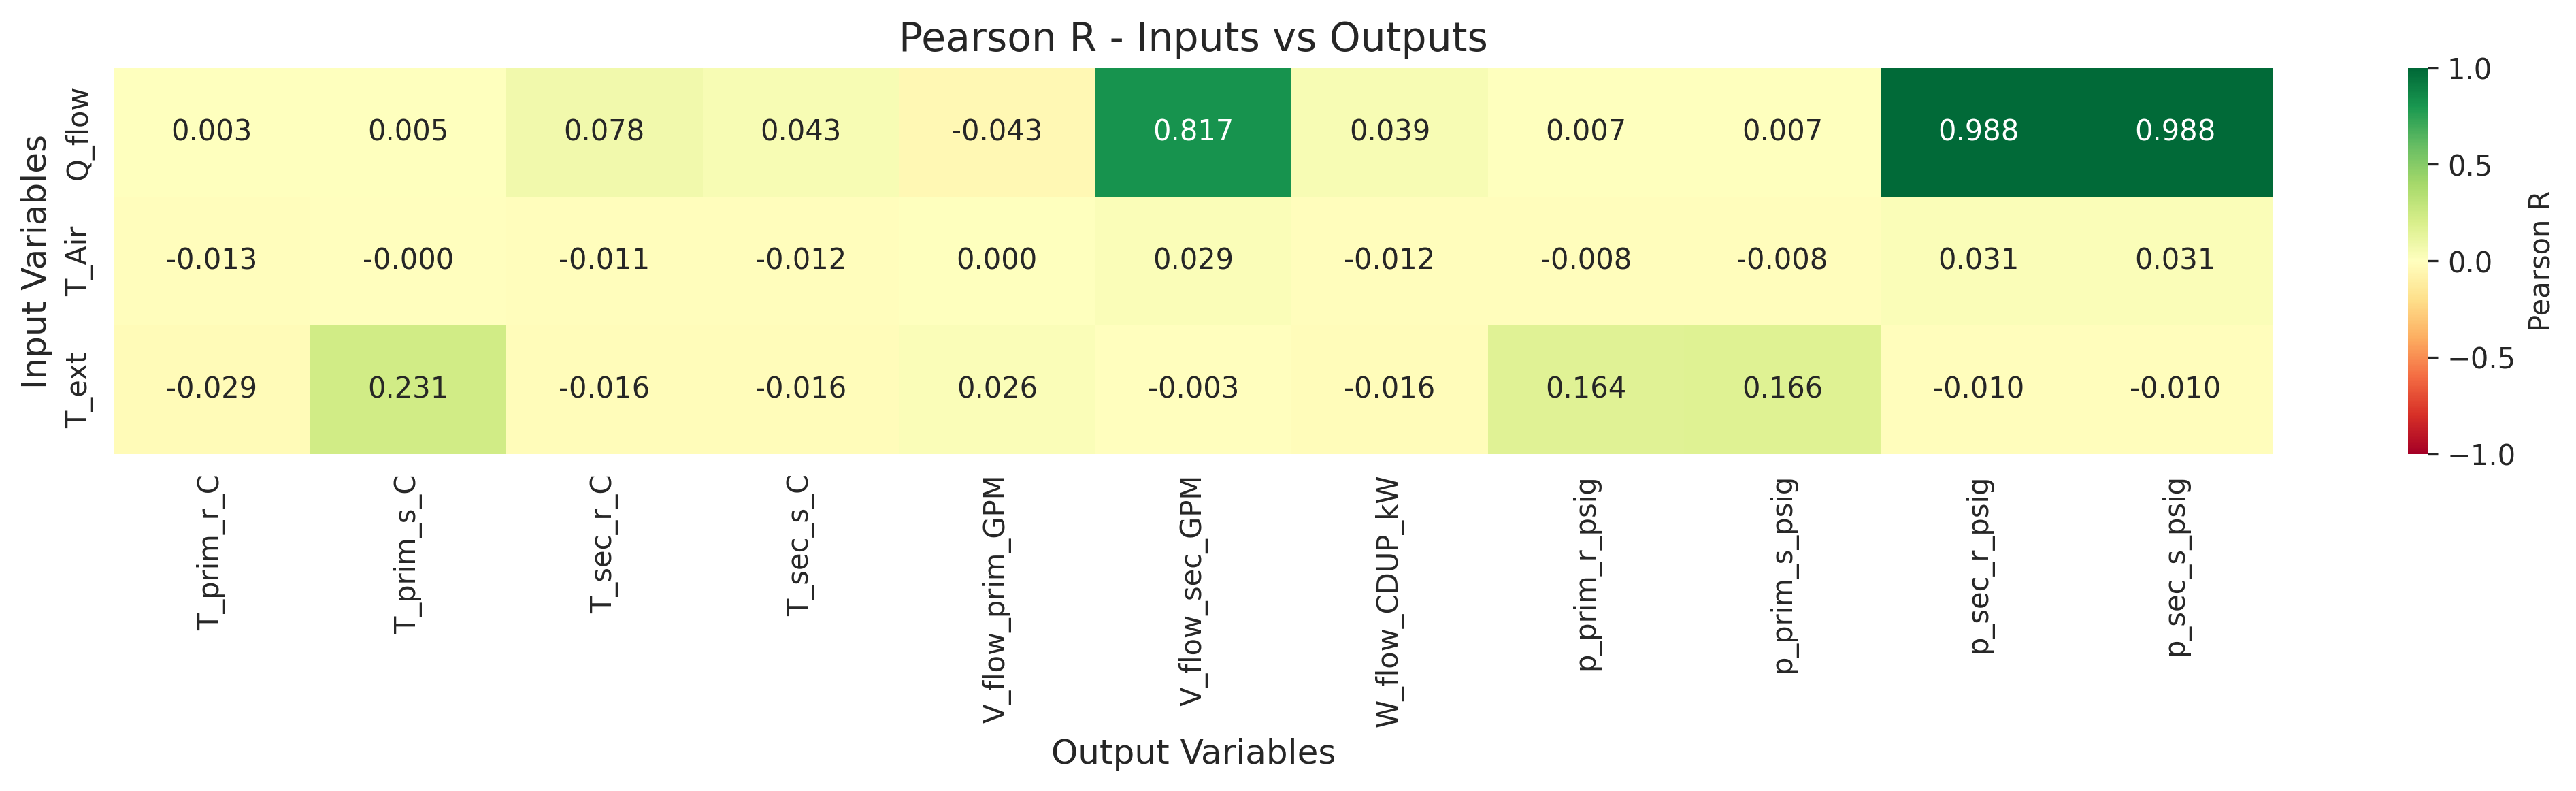

In [12]:
# Correlation Heatmaps
create_correlation_heatmap(metrics_df, OUTPUT_DIR, n_workers=N_WORKERS)
print(f"Heatmaps saved to {OUTPUT_DIR}")

# Display one heatmap inline
from IPython.display import Image
Image(filename=os.path.join(OUTPUT_DIR, 'heatmap_pearson_r.png'))


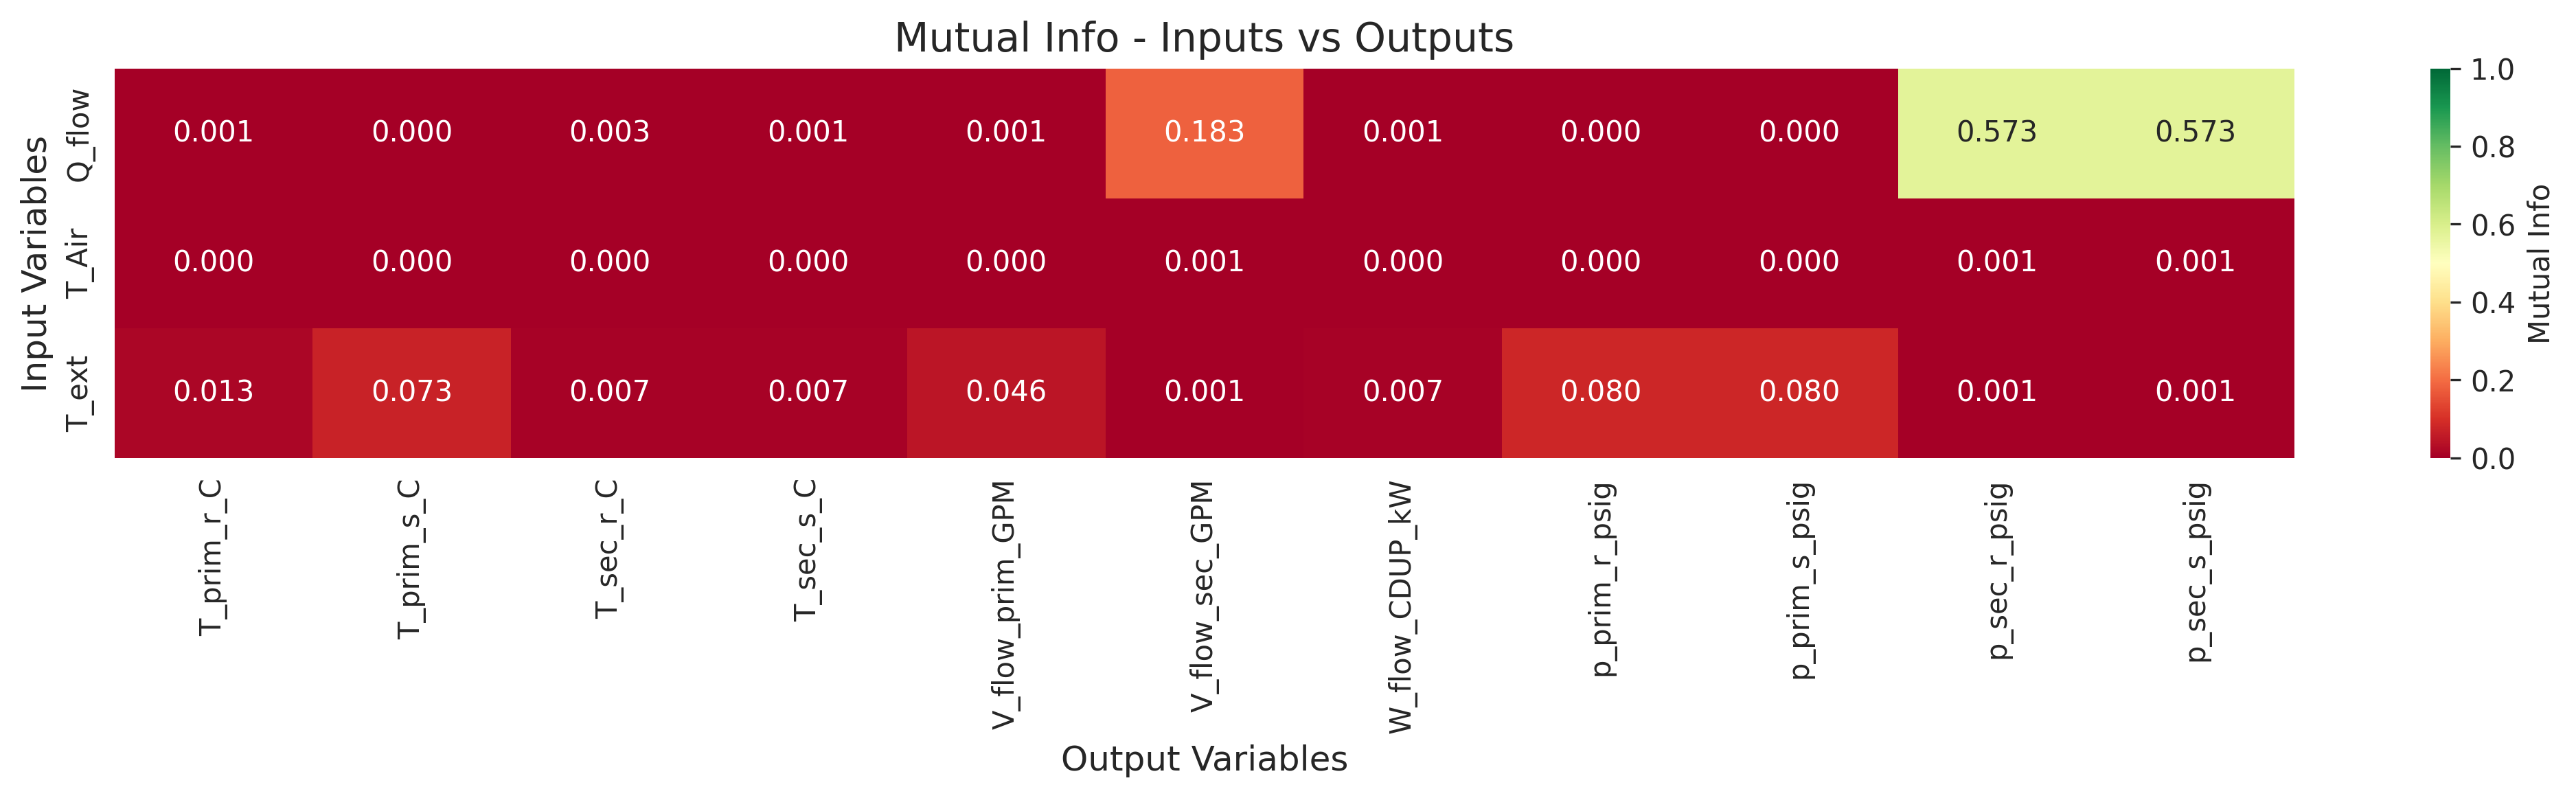

In [13]:
Image(filename=os.path.join(OUTPUT_DIR, 'heatmap_mutual_info.png'))
# heatmap_mutual_info.png   heatmap_r2_score.png     
# heatmap_pearson_r.png     heatmap_spearman_r.png   

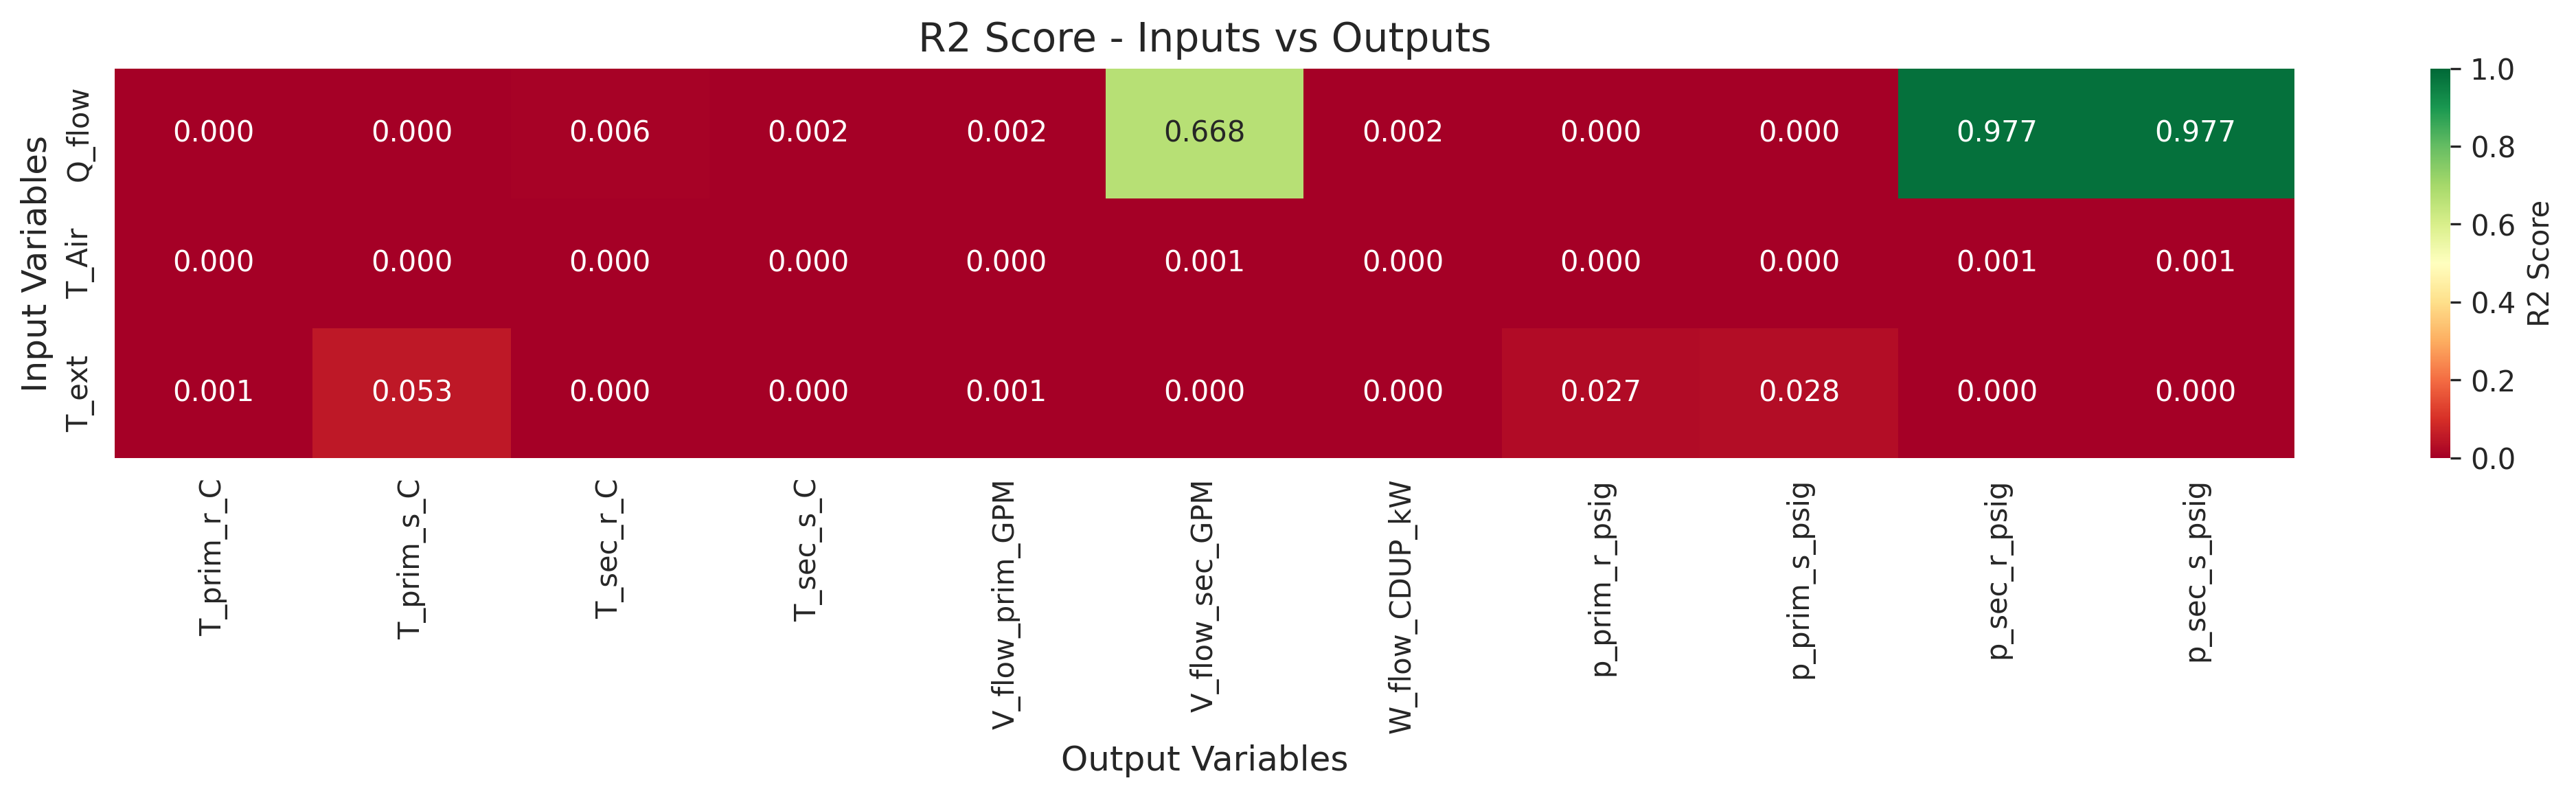

In [14]:
Image(filename=os.path.join(OUTPUT_DIR, 'heatmap_r2_score.png'))


## Isolated Effects Analysis

In [15]:

# After running analyze_isolated_effects
isolated_df = analyzer.analyze_isolated_effects(prepared_data, tolerance=0.1)


2026-02-03 08:19:23 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Analyzing isolated input effects (others held at mean)...
2026-02-03 08:19:23 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO -   Q_flow: 7338 samples with others at mean
2026-02-03 08:19:23 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO -   T_Air: 7678 samples with others at mean
2026-02-03 08:19:23 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO -   T_ext: 7957 samples with others at mean


In [16]:

# Create visualizations
create_isolated_effect_heatmap(isolated_df, output_dir=OUTPUT_DIR)
create_isolated_effect_comparison(metrics_df, isolated_df, output_dir=OUTPUT_DIR)
create_isolated_effect_summary(isolated_df, output_dir=OUTPUT_DIR)

2026-02-03 08:19:24 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Creating isolated effect heatmaps...
2026-02-03 08:19:26 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Created isolated effect heatmaps for 3 metrics
2026-02-03 08:19:26 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Creating isolated vs full effect comparison plots...
2026-02-03 08:19:33 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Created comparison plots for 3 inputs
2026-02-03 08:19:33 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Creating isolated effect summary plots...
2026-02-03 08:19:35 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Created isolated effect summary plot


2026-02-03 08:22:38 - fmu2ml.analysis.input_output_relations.visualizers.scatter_visualizer - INFO - Creating scatter plots in parallel...
2026-02-03 08:22:45 - fmu2ml.analysis.input_output_relations.visualizers.scatter_visualizer - INFO - Created scatter plots for 3 inputs


Scatter plots saved to ../results/summit/data_analysis/direct_effect_analysis


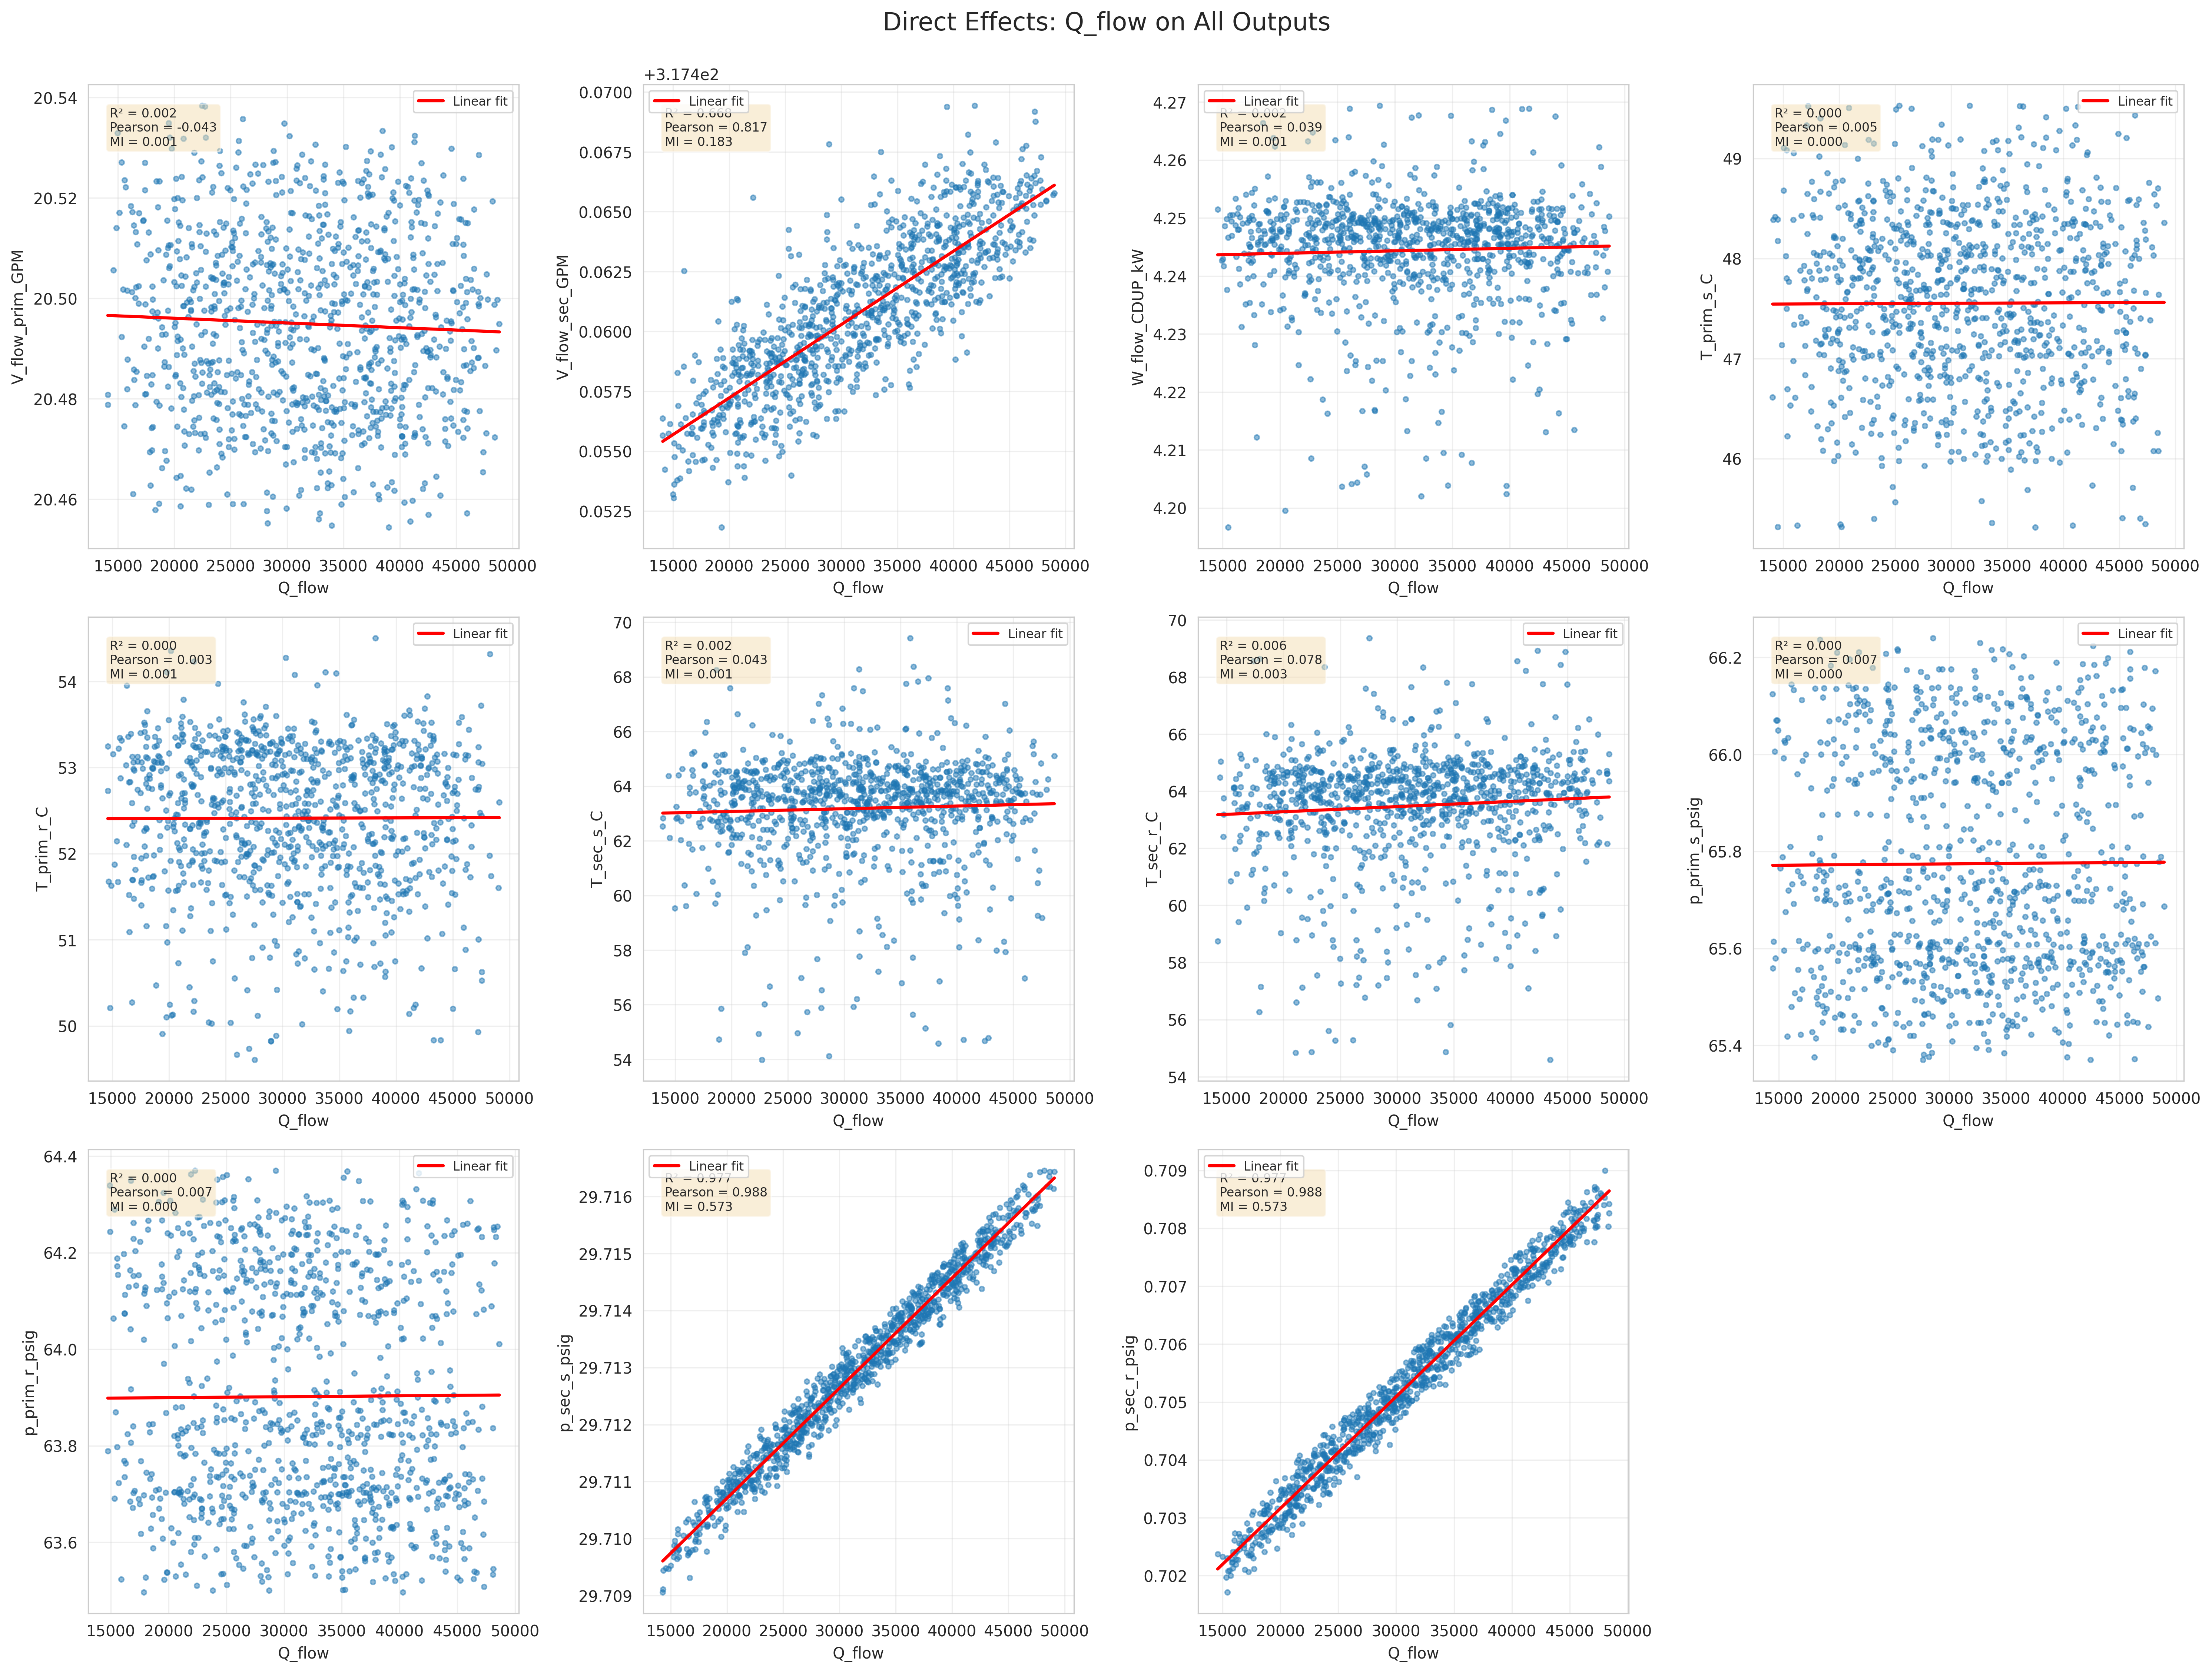

In [17]:
# Scatter Plots for Key Relationships
create_scatter_plots(prepared_data, metrics_df, OUTPUT_DIR, n_workers=N_WORKERS)
print(f"Scatter plots saved to {OUTPUT_DIR}")

# Display example scatter plot
Image(filename=os.path.join(OUTPUT_DIR, 'scatter_plots_Q_flow.png'))
# scatter_plots_T_ext.png   scatter_plots_T_Air.png

2026-02-03 08:22:45 - fmu2ml.analysis.input_output_relations.visualizers.ranking_visualizer - INFO - Creating importance ranking plots...
2026-02-03 08:22:47 - fmu2ml.analysis.input_output_relations.visualizers.ranking_visualizer - INFO - Saved importance ranking plots to ../results/summit/data_analysis/direct_effect_analysis


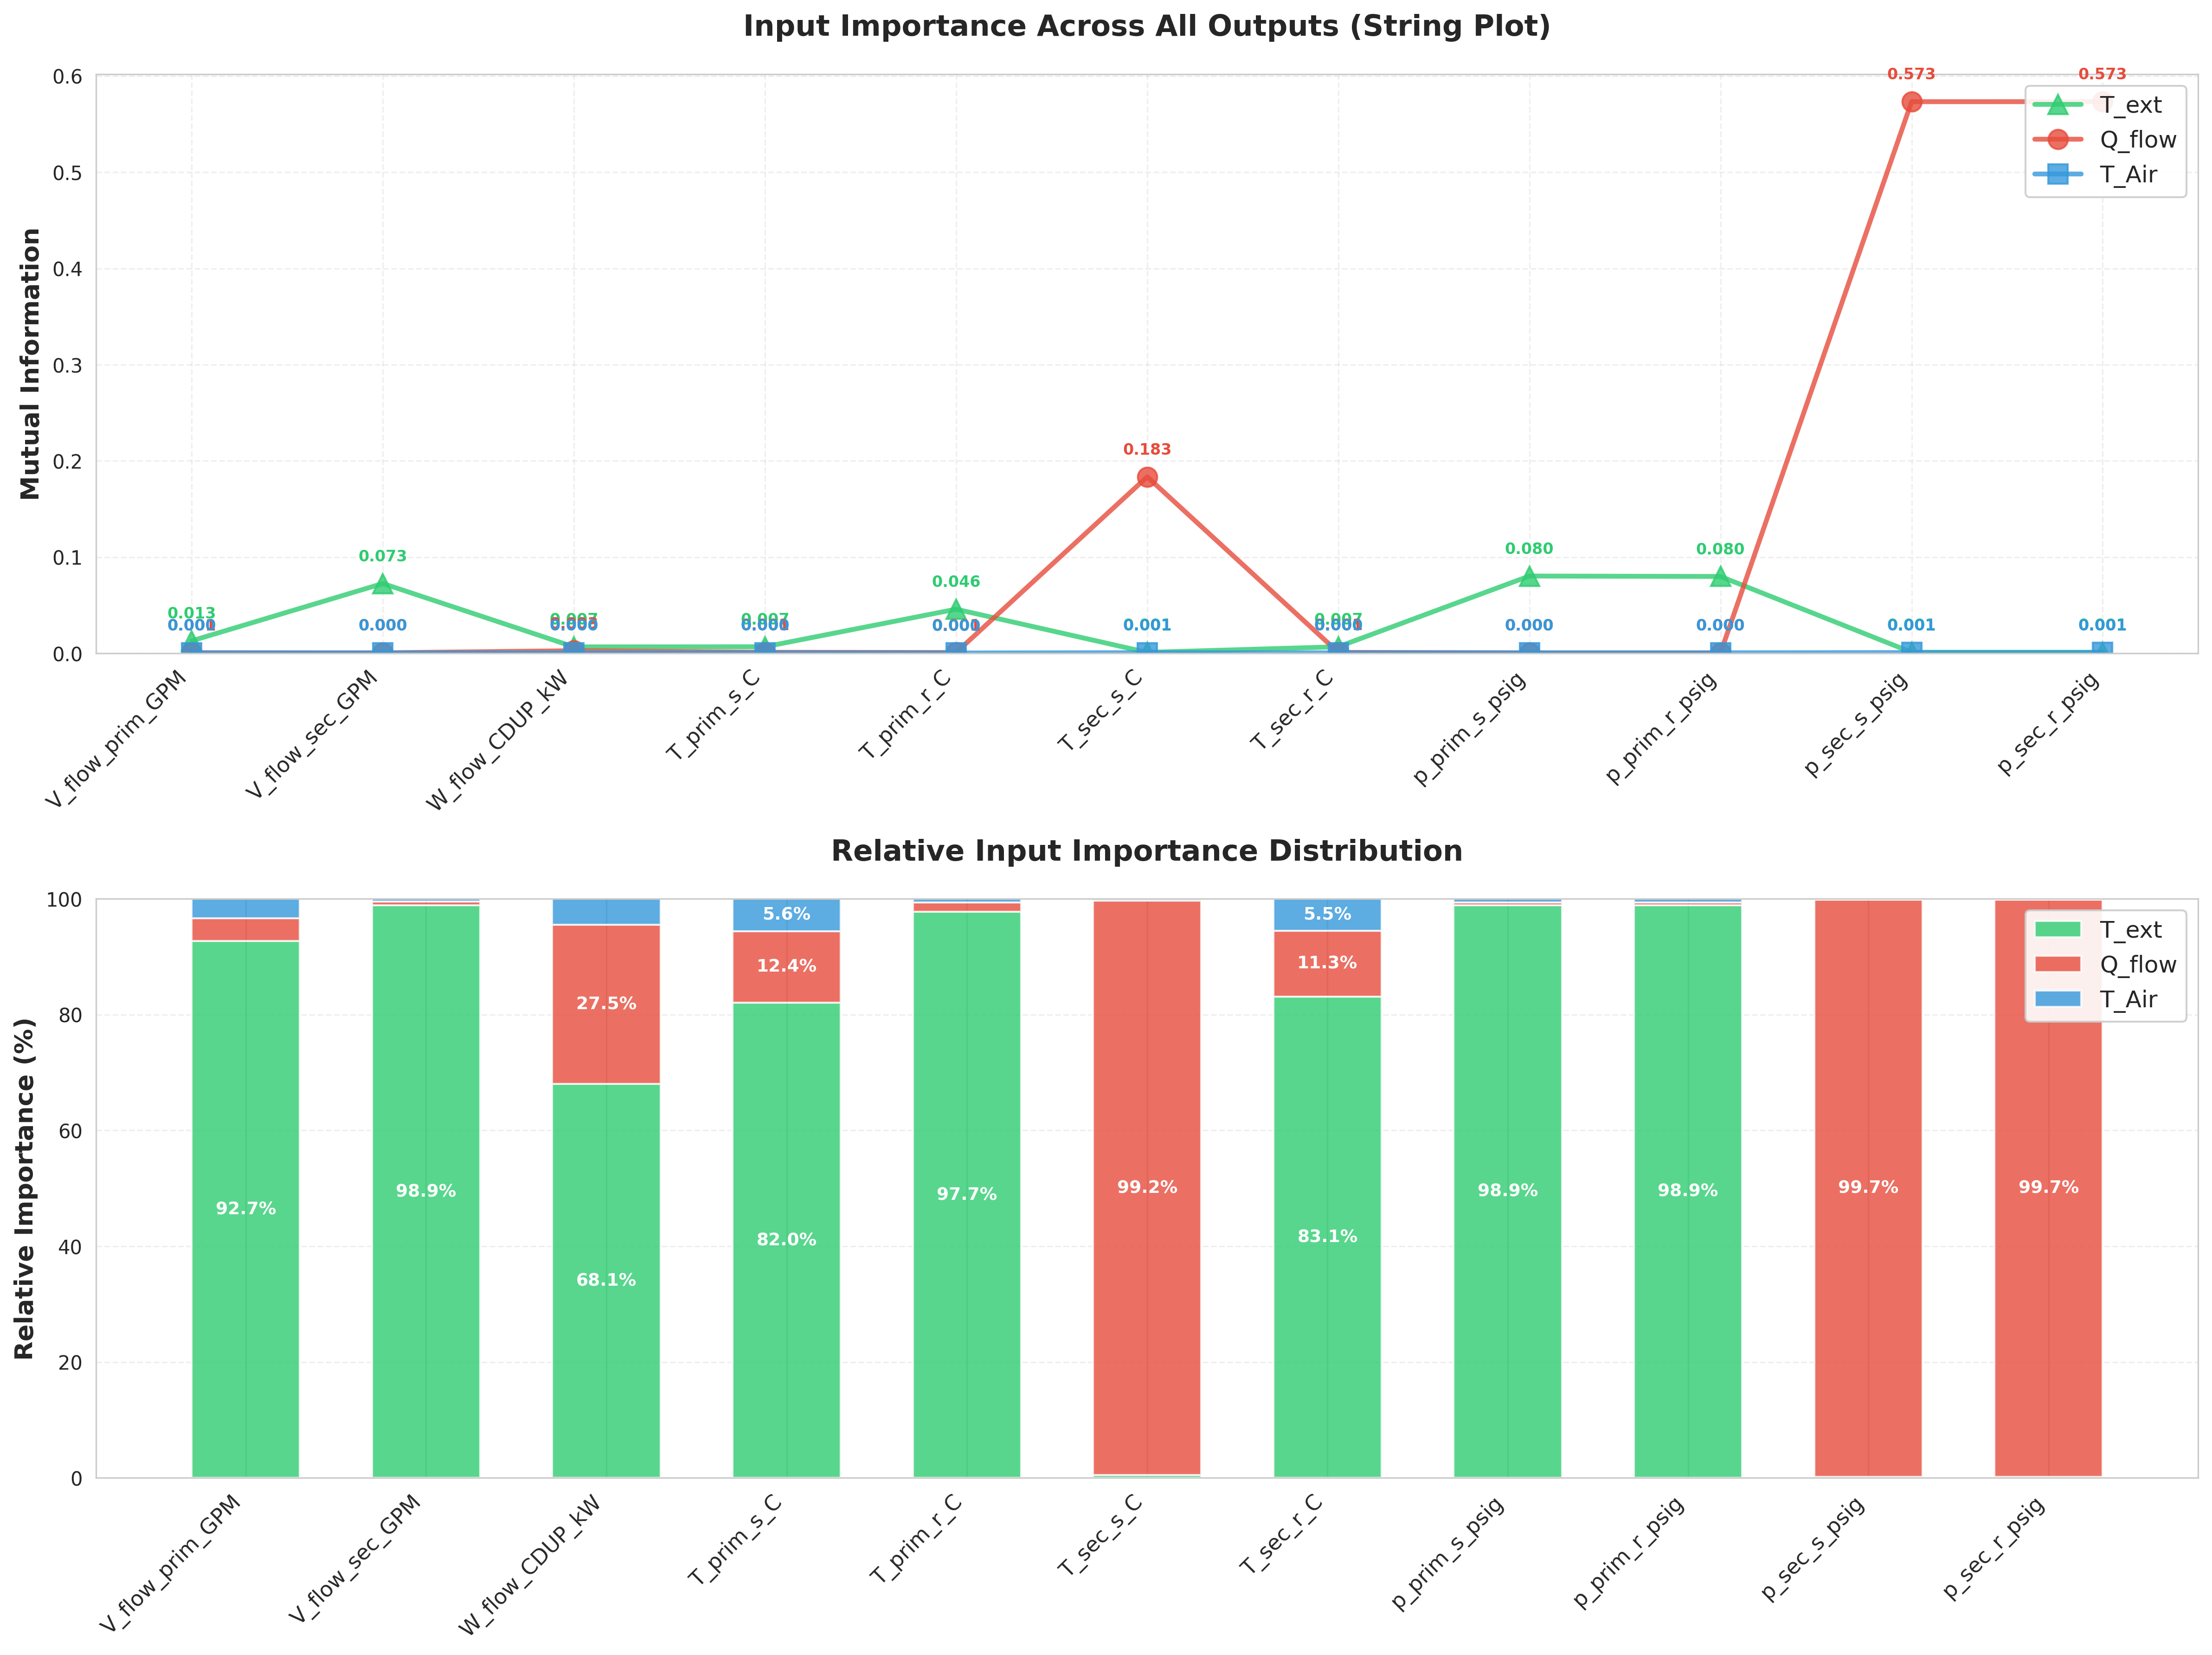

In [18]:
# Importance Ranking Plots
create_importance_ranking_plots(rankings_df, OUTPUT_DIR)
Image(filename=os.path.join(OUTPUT_DIR, 'importance_rankings.png'))


## Interaction Effects Analysis


In [19]:
print("Analyzing interaction effects...")
interaction_df = analyzer.analyze_all_interaction_effects(prepared_data)


2026-02-03 08:22:47 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Analyzing interaction effects for all outputs in parallel...
2026-02-03 08:22:47 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Executing 11 interaction analysis tasks...


Analyzing interaction effects...


In [20]:
interaction_df

,output,r2_linear,r2_polynomial,interaction_effect
0,V_flow_prim_GPM,0.002552,0.007655,0.005103
1,V_flow_sec_GPM,0.668267,0.668790,0.000523
2,W_flow_CDUP_kW,0.001942,0.002260,0.000318
3,T_prim_s_C,0.053446,0.062149,0.008703
4,T_prim_r_C,0.001049,0.005021,0.003972
5,T_sec_s_C,0.002238,0.002562,0.000324
6,T_sec_r_C,0.006429,0.006754,0.000324
7,p_prim_s_psig,0.027704,0.035585,0.007881
8,p_prim_r_psig,0.026943,0.034831,0.007888
9,p_sec_s_psig,0.977850,0.978345,0.000495


## Response Surfaces Analysis

In [21]:
# # Response Surfaces 
key_outputs = ['T_prim_r_C', 'W_flow_CDUP_kW', 'V_flow_prim_GPM']
# key_outputs = ['T_sec_s_C','p_sec_s_psig','p_prim_r_psig']
input_pairs = [('Q_flow', 'T_Air'), ('Q_flow', 'T_ext'), ('T_Air', 'T_ext')]

# Fixed inputs (middle of ranges)
fixed_inputs = {
    'Q_flow': (INPUT_RANGES['Q_flow'][0] + INPUT_RANGES['Q_flow'][1]) / 2 * 1000,
    'T_Air': (INPUT_RANGES['T_Air'][0] + INPUT_RANGES['T_Air'][1]) / 2,
    'T_ext': (INPUT_RANGES['T_ext'][0] + INPUT_RANGES['T_ext'][1]) / 2
}

# Generate all response surface data
all_surface_data = {}
for input1, input2 in input_pairs:
    print(f"Generating surface data: {input1} x {input2}")
    
    # Remove varying inputs from fixed_inputs
    current_fixed = {k: v for k, v in fixed_inputs.items() 
                    if k not in (input1, input2)}
    
    # Set ranges with unit conversion for Q_flow
    input1_range = (INPUT_RANGES[input1][0]*1000, INPUT_RANGES[input1][1]*1000) if input1 == 'Q_flow' else INPUT_RANGES[input1]
    input2_range = (INPUT_RANGES[input2][0]*1000, INPUT_RANGES[input2][1]*1000) if input2 == 'Q_flow' else INPUT_RANGES[input2]
    
    surface_data = data_generator.generate_response_surface_data(
        input1=input1, 
        input2=input2,
        input1_range=input1_range,
        input2_range=input2_range,
        n_points_per_dim=20,
        fixed_inputs=current_fixed,
        n_workers=N_WORKERS,
        use_parallel=True
    )
    
    all_surface_data[(input1, input2)] = surface_data

# Compute response surfaces using DirectEffectAnalyzer
surfaces = {}
for output in key_outputs:
    for input1, input2 in input_pairs:
        print(f"Computing surface: {output} vs {input1} x {input2}")
        
        surface_data = all_surface_data[(input1, input2)]
        surface_prepared = analyzer.prepare_data(surface_data)
        
        # Use the static method directly
        input1_data = surface_prepared['inputs'][input1]
        input2_data = surface_prepared['inputs'][input2]
        output_data = surface_prepared['outputs'][output]
        
        X, Y, Z = analyzer._compute_response_surface_static(
            input1_data, input2_data, output_data, n_points=20
        )
        
        surfaces[(output, input1, input2)] = (X, Y, Z)

# Create plots
create_response_surface_plots(surfaces, OUTPUT_DIR, n_workers=N_WORKERS)

# Display first plot
Image(filename=os.path.join(OUTPUT_DIR, f'response_surface_{key_outputs[0]}_Q_flow_T_Air.png'))

In [22]:
# Image(filename=os.path.join(OUTPUT_DIR,'response_surface_W_flow_CDUP_kW_Q_flow_T_ext.png'))


In [23]:
# Image(filename=os.path.join(OUTPUT_DIR,'response_surface_V_flow_prim_GPM_Q_flow_T_ext.png'))


2026-02-03 08:22:58 - fmu2ml.analysis.input_output_relations.visualizers.slice_visualizer - INFO - Creating slice plots: T_prim_r_C vs Q_flow at different T_ext levels...
2026-02-03 08:22:59 - fmu2ml.analysis.input_output_relations.visualizers.slice_visualizer - INFO - Created slice plots for 1 outputs


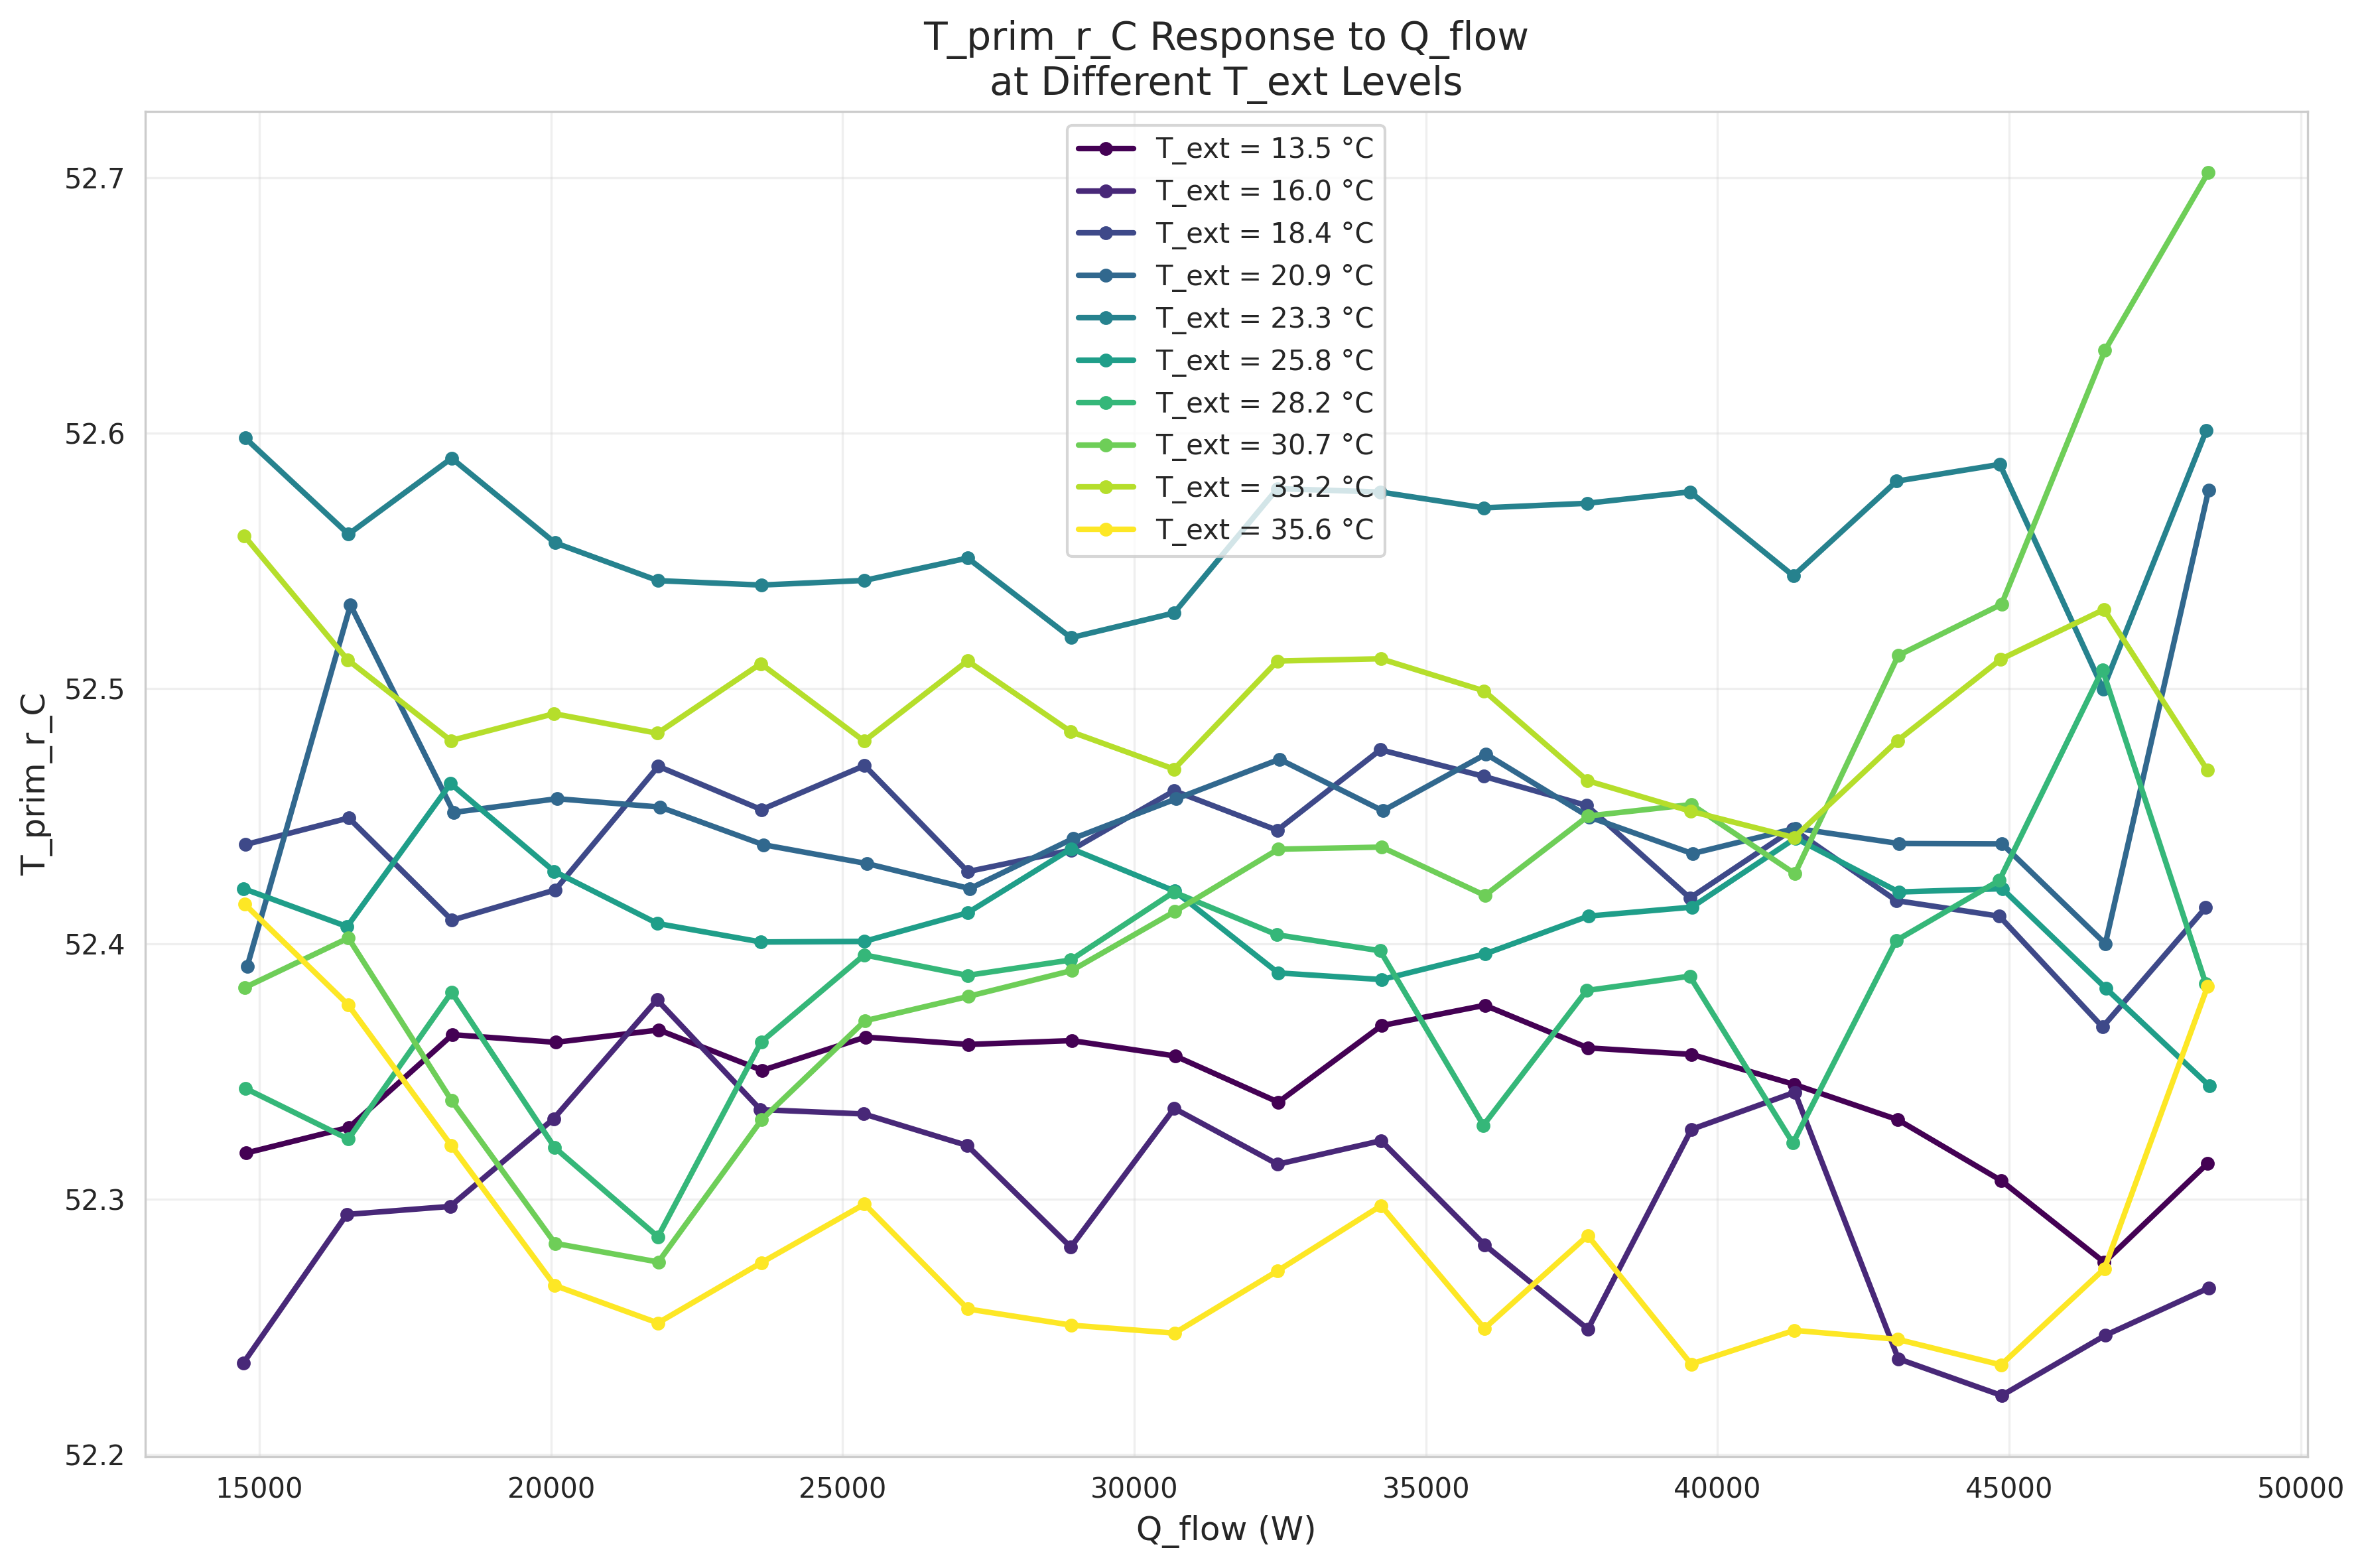

In [24]:

# Slice Plots
create_slice_plots(
    prepared_data,
    output_vars=['T_prim_r_C'],
    input1='Q_flow',
    input2='T_ext',
    n_slices=10,
    output_dir=OUTPUT_DIR
)
Image(filename=os.path.join(OUTPUT_DIR, 'slice_plot_T_prim_r_C_Q_flow_vs_T_ext.png'))


## Summary Statistics


In [25]:

# Summary Statistics
print("="*60)
print("ANALYSIS SUMMARY")
print("="*60)

print(f"\nTotal input-output pairs analyzed: {len(metrics_df)}")
print(f"Strong correlations (|r| > 0.7): {len(metrics_df[abs(metrics_df['pearson_r']) > 0.7])}")
print(f"High mutual information (> 0.5): {len(metrics_df[metrics_df['mutual_info'] > 0.5])}")
print(f"Good fits (R² > 0.8): {len(metrics_df[metrics_df['r2_score'] > 0.8])}")

print("\nTop 3 most important inputs overall:")
overall_importance = metrics_df.groupby('input')['mutual_info'].mean().sort_values(ascending=False)
print(overall_importance.head(3))


ANALYSIS SUMMARY

Total input-output pairs analyzed: 33
Strong correlations (|r| > 0.7): 3
High mutual information (> 0.5): 2
Good fits (R² > 0.8): 2

Top 3 most important inputs overall:
input
Q_flow    0.121565
T_ext     0.028587
T_Air     0.000508
Name: mutual_info, dtype: float64


In [26]:

# Save Results
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'sensitivity_metrics.csv'), index=False)
rankings_df.to_csv(os.path.join(OUTPUT_DIR, 'input_rankings.csv'), index=False)
interaction_df.to_csv(os.path.join(OUTPUT_DIR, 'interaction_effects.csv'), index=False)

print(f"\nResults saved to: {OUTPUT_DIR}")



Results saved to: ../results/summit/data_analysis/direct_effect_analysis


In [ ]:

# Cleanup
analyzer._close_dask_client()
print("Analysis complete!")